# PLI-Parallax: validation notebook

Recomputes the quantities reported in Utility and Discussion from the deposited database alone.
Section A reproduces the deposited reliability annotation, its calibration and the per-residue support gradient.
Section B examines the dependence of the annotation on binding-site access and its transfer to the corpus tier.
Section C examines calibration and support across the structural training cutoffs of the cofolding models.
A final cell collects every quoted value against its recomputation and exports tables and figures.

In [1]:
# setup, download of the tabular layer and verification against the manifest
import os, hashlib, time
import numpy as np, pandas as pd
import pyarrow as pa, pyarrow.parquet as pq
import scipy, sklearn, matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from huggingface_hub import snapshot_download
for m in (np, pd, pa, scipy, sklearn, matplotlib): print(f"{m.__name__:12s} {m.__version__}")

SEED, B, K = 0, 1000, 5       # seed, bootstrap resamples, cross-validation folds
STRICT = False                # raise in the final cell if a quoted value is not reproduced
RUN_SHIFT = True              # covariate-shift diagnostic in section B
BASIS = "release"             # date basis of the temporal configurations
CUTOFF = {"chai1": "2021-01-12", "boltz2": "2023-06-01"}   # stated structural training cutoffs
OUT = "validation_outputs"; os.makedirs(OUT, exist_ok=True)
T0 = time.time()

D = os.path.join(snapshot_download(repo_id="ThorKl/PLI-parallax", repo_type="dataset",
    allow_patterns=["deposit/labels/*", "deposit/metadata/*", "deposit/splits/*", "deposit/MANIFEST.sha256"]), "deposit")
def sha256(p, chunk=1 << 22):
    h = hashlib.sha256()
    with open(p, "rb") as fh:
        for b in iter(lambda: fh.read(chunk), b""): h.update(b)
    return h.hexdigest()
man = [l.strip().split("  ", 1) for l in open(f"{D}/MANIFEST.sha256") if l.strip()]
need = [(w, r) for w, r in man if r.split("/")[0] in ("labels", "metadata", "splits")]
bad = [r for w, r in need if not os.path.exists(f"{D}/{r}") or sha256(f"{D}/{r}") != w]
print(f"{len(need)} tabular files verified, failing: {bad or 'none'}")
assert not bad

numpy        2.1.3
pandas       2.2.3
pyarrow      23.0.1
scipy        1.16.3
sklearn      1.6.1
matplotlib   3.10.0


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 33 files:   0%|          | 0/33 [00:00<?, ?it/s]

32 tabular files verified, failing: none


In [2]:
# library: loaders, contact sets, calibration, bootstrap, support gradient, era labels, figure system
ARMS = ("chai1", "boltz2", "smina")
PAIRS = [("chai1", "boltz2"), ("chai1", "smina"), ("boltz2", "smina")]
PN = [f"{a}_{b}" for a, b in PAIRS]

# values quoted in the revised manuscript: (value, tolerance); recomputed values are the reference
QUOTED = {
    "n_agreement": (7134, 0), "n_cohort": (7129, 0), "acc_mean": (0.3951, 1e-4),
    "acc_chai1": (0.4443, 1e-4), "acc_boltz2": (0.1816, 1e-4), "acc_smina": (0.5595, 1e-4),
    "agr_crystal_chai1_boltz2": (0.1909, 1e-4), "agr_crystal_chai1_smina": (0.3366, 1e-4),
    "agr_corpus_chai1_boltz2": (0.1224, 1e-4), "agr_corpus_chai1_smina": (0.1218, 1e-4),
    "agr_corpus_boltz2_smina": (0.0798, 1e-4), "agr_mean_crystal": (0.2254, 1e-4), "agr_mean_corpus": (0.1080, 1e-4),
    "cv_mae_iso": (0.0813, 1e-4), "cv_mae_const": (0.1734, 1e-4), "halfwidth_90": (0.1541, 1e-4),
    "t8_kept_040": (3495, 0), "t8_acc_040": (0.5487, 1e-4),
    "prec_1": (0.2175, 1e-4), "prec_2": (0.7265, 1e-4), "prec_3": (0.9356, 1e-4),
    "frac_1": (0.7065, 1e-4), "frac_3": (0.0774, 1e-4), "union_recall": (0.8828, 1e-4),
    # site access
    "retained_chai1_boltz2": (0.2724, 1e-3), "retained_chai1_smina": (0.8747, 1e-3),
    "skill_cofolder_target": (0.1897, 1e-3), "rho_corpus_orderings": (0.722, 1e-3),
    "enrich_retained_top10": (0.636, 2e-3), "enrich_retained_top50": (0.523, 2e-3),
    # training cutoffs
    "prec3_post_chai1": (0.9336, 1e-4), "prec3_post_boltz2": (0.9288, 1e-4),
    "dacc_chai1_at_chai1": (-0.0470, 1e-3), "dacc_boltz2_at_chai1": (-0.0255, 1e-3),
    "dacc_chai1_at_boltz2": (-0.0322, 1e-3), "dacc_boltz2_at_boltz2": (-0.0388, 1e-3)}
LOG = {}
def check(key, got): LOG[key] = float(got)

def lab(arm, tier, kind):
    stem = "crystal_groundtruth" if arm == "gt" else f"{arm}_{tier}"
    return f"{D}/labels/labels_{stem}_{kind}.parquet"
def meta(arm, tier, cols=("system_id", "protein_id", "has_contacts")):
    return pq.read_table(lab(arm, tier, "meta"), columns=list(cols)).to_pandas()
def contacts4(arm, tier, keep):
    # residues with a ligand heavy atom within 4 A; res_row is shared across all label files
    t = pq.read_table(lab(arm, tier, "contacts"), columns=["system_id", "res_row"],
                      filters=[("contact_4A", "==", True)]).to_pandas().drop_duplicates()
    return t[t.system_id.isin(keep)].assign(**{arm: True})
def residue_sets(tier, arms):
    keep = set.intersection(*[set(meta(a, tier).query("has_contacts").system_id) for a in arms])
    R = None
    for a in arms:
        c = contacts4(a, tier, keep)
        R = c if R is None else R.merge(c, on=["system_id", "res_row"], how="outer")
    R[list(arms)] = R[list(arms)].notna()
    return R, sorted(keep)
def nonempty(R, keep, arms):
    nz = R.groupby("system_id")[list(arms)].sum().reindex(keep).fillna(0) > 0
    return set(nz.index[nz.all(axis=1)])
def jaccard(R, ids, a, b):
    inter, union = (R[a] & R[b]).groupby(R.system_id).sum(), (R[a] | R[b]).groupby(R.system_id).sum()
    return (inter / union).reindex(ids)

def cvp(x, y, fit, groups=None):
    cv = GroupKFold(K) if groups is not None else KFold(K, shuffle=True, random_state=SEED)
    p = np.empty(len(y))
    for tr, te in cv.split(x, y, groups): p[te] = fit(x[tr], y[tr])(x[te])
    return p
ISO = lambda x, y: IsotonicRegression(out_of_bounds="clip").fit(x, y).predict
CONST = lambda x, y: (lambda z, m=y.mean(): np.full(len(z), m))
LIN = lambda x, y: (lambda z, f=LinearRegression().fit(x[:, None], y): f.predict(z[:, None]))
mae = lambda y, p: float(np.mean(np.abs(y - p)))
rho = lambda a, b: spearmanr(a, b)[0]
def boot(stat, *arrs, b=B):
    n = len(arrs[0]); I = np.random.default_rng(SEED).integers(0, n, (b, n))
    return np.percentile([stat(*(a[i] for a in arrs)) for i in I], [2.5, 97.5])
def fmt(ci, d=3): return f"[{ci[0]:.{d}f}, {ci[1]:.{d}f}]"
def rho_ci(a, b, chunk=100):
    # bootstrap interval of the Spearman correlation: ranks computed once, Pearson on resampled ranks, vectorised
    from scipy.stats import rankdata
    ra, rb, n = rankdata(a), rankdata(b), len(a); g_ = np.random.default_rng(SEED); out = []
    for s0 in range(0, B, chunk):
        I = g_.integers(0, n, (min(chunk, B - s0), n)); A, Z = ra[I], rb[I]
        A = A - A.mean(1, keepdims=True); Z = Z - Z.mean(1, keepdims=True)
        out.append((A * Z).sum(1) / np.sqrt((A * A).sum(1) * (Z * Z).sum(1)))
    return np.percentile(np.concatenate(out), [2.5, 97.5])
def diff_ci(a, b, stat=np.nanmean):
    # stat(b) - stat(a) for independent groups, resampled within each group
    g_ = np.random.default_rng(SEED)
    d = [stat(b[g_.integers(0, len(b), len(b))]) - stat(a[g_.integers(0, len(a), len(a))]) for _ in range(B)]
    return stat(b) - stat(a), np.percentile(d, [2.5, 97.5])
def ratio_diff_ci(h0, n0, h1, n1):
    # pooled ratio sum(h1)/sum(n1) - sum(h0)/sum(n0), systems resampled within each group
    g_ = np.random.default_rng(SEED); d = []
    for _ in range(B):
        i0, i1 = g_.integers(0, len(h0), len(h0)), g_.integers(0, len(h1), len(h1))
        d.append(h1[i1].sum() / n1[i1].sum() - h0[i0].sum() / n0[i0].sum())
    return h1.sum() / n1.sum() - h0.sum() / n0.sum(), np.percentile(d, [2.5, 97.5])
excl = lambda ci: bool(ci[0] > 0 or ci[1] < 0)

def cluster_ratio_boot(num, den):
    # num, den: systems x levels; resamples systems
    n = num.shape[0]
    W = np.random.default_rng(SEED).multinomial(n, np.full(n, 1 / n), size=B)
    return num.sum(0) / den.sum(0), np.percentile((W @ num) / (W @ den), [2.5, 97.5], axis=0)
def gradient(rs, gt):
    # precision by number of asserting teachers, row fractions and union recall, with 95 % intervals
    sid = pd.Index(sorted(rs.system_id.unique()))
    per = lambda df, c, f: df.groupby("system_id")[c].agg(f).reindex(sid).fillna(0).values
    num = np.stack([per(rs[rs.n_teachers_asserting == k], "true", "sum") for k in (1, 2, 3)], 1).astype(float)
    den = np.stack([per(rs[rs.n_teachers_asserting == k], "true", "size") for k in (1, 2, 3)], 1).astype(float)
    hit = per(rs[rs.true], "true", "size").astype(float)[:, None]
    tot = per(gt[gt.system_id.isin(sid)], "res_row", "size").astype(float)[:, None]
    p, ci = cluster_ratio_boot(num, den); r, rci = cluster_ratio_boot(hit, tot)
    out = {"n_systems": len(sid)}
    for k in range(3):
        out.update({f"prec_{k+1}": p[k], f"prec_{k+1}_lo": ci[0, k], f"prec_{k+1}_hi": ci[1, k],
                    f"frac_{k+1}": den[:, k].sum() / den.sum()})
    out.update({"union_recall": r[0], "recall_lo": rci[0, 0], "recall_hi": rci[1, 0]})
    return out

def feature_row(name, xf, yt, ref=None):
    # isotonic calibration of target yt on feature xf; ref = (constant, three-arm) predictions on the same target
    p, p0 = cvp(xf, yt, ISO), cvp(xf, yt, CONST)
    r = {"feature": name, "mae_cv": mae(yt, p), "mae_constant": mae(yt, p0), "skill": 1 - mae(yt, p) / mae(yt, p0),
         "spearman": rho(xf, yt), "spearman_ci": fmt(rho_ci(xf, yt)), "kendall": kendalltau(xf, yt)[0]}
    if ref is not None:
        c, f = ref
        ret = lambda y_, c_, f_, v_: (mae(y_, c_) - mae(y_, v_)) / (mae(y_, c_) - mae(y_, f_))
        ci = boot(ret, yt, c, f, p)
        r.update({"retained": ret(yt, c, f, p), "retained_ci": fmt(ci)})
        r["verdict"] = "robust" if ci[0] >= 0.8 else ("partial" if r["retained"] >= 0.5 else "weak")
    return r, p

def era_labels(model, TI, TS, index):
    # post-cutoff membership from the deposited temporal configuration nearest the model cutoff
    t = TI.assign(dd=(pd.to_datetime(TI.test_start) - pd.Timestamp(CUTOFF[model])).abs(), ob=(TI.date_basis != BASIS))
    r = t.sort_values(["dd", "ob"]).iloc[0]
    assert r.dd.days <= 31, f"no temporal configuration at the {model} cutoff"
    f = TS[TS.split_tag == r.split_tag].set_index("system_id").fold.reindex(index)
    return f.eq("test").values, f.notna().values & ~f.eq("test").values, r.split_tag

# figure system: native size in mm, one font size per role, colour by role as in the manuscript figures
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
MM = 1 / 25.4
W1, W2, HMAX = 84 * MM, 174 * MM, 234 * MM     # journal column widths and height cap, in inches
FS_PANEL, FS_LABEL, FS_TICK, FS_ANNO, FS_MIN = 11, 8, 7, 6.5, 5.5
COLORS = {"field": "#2B5EA7", "blind": "#C8912A", "chai1": "#2B5EA7", "boltz2": "#6C99D8", "smina": "#A0C1EF",
          "lvl1": "#A0C1EF", "lvl2": "#6C99D8", "lvl3": "#2B5EA7", "pre": "#6C99D8", "post": "#FFCC00",
          "crystal": "#2B5EA7", "corpus": "#A0C1EF", "baseline": "#D9D9D9", "baseline_ed": "#888888",
          "reference": "#2C2C2C", "grid": "#CCCCCC"}
ALT = {}
plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FS_TICK, "axes.labelsize": FS_LABEL, "xtick.labelsize": FS_TICK, "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_ANNO, "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.6,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6, "lines.linewidth": 1.2, "savefig.dpi": 300,
    "figure.dpi": 150, "pdf.fonttype": 42})

def clean(ax, grid="y"):
    ax.set_axisbelow(True)
    if grid: ax.grid(axis=grid, alpha=0.28, color=COLORS["grid"], linewidth=0.5, linestyle="--")
def panel(ax, letter, x=-0.16, y=1.07):
    ax.text(x, y, letter, transform=ax.transAxes, fontsize=FS_PANEL, fontweight="bold", ha="left", va="top")
def note(ax, x, y, text, ha="right", va="top"):
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=FS_ANNO,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.88, edgecolor=COLORS["grid"], linewidth=0.5))
def refline(ax, v, label, axis="h", pos=0.5):
    (ax.axhline if axis == "h" else ax.axvline)(v, color=COLORS["reference"], linestyle=":", linewidth=0.9)
    tr = ax.get_yaxis_transform() if axis == "h" else ax.get_xaxis_transform()
    xy = (pos, v) if axis == "h" else (v, pos)
    ax.text(*xy, label, transform=tr, ha="center", va="bottom", fontsize=FS_ANNO, color=COLORS["reference"],
            rotation=0 if axis == "h" else 90)
def read(name):
    p = f"{OUT}/{name}.csv"
    if not os.path.exists(p): raise FileNotFoundError(f"{p} not found; run the section that writes it")
    return pd.read_csv(p)
def save(fig, name, alt):
    for ext in ("pdf", "png"):
        p = f"{OUT}/{name}.{ext}"
        fig.savefig(p, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
    mb = os.path.getsize(f"{OUT}/{name}.pdf") / 1e6
    print(f"{name}: {mb:.2f} MB{'  over 2 MB' if mb > 2 else ''}")
    ALT[name] = alt; plt.show(); plt.close(fig)

## Section A: reproduction of the deposited annotation, calibration and support gradient

In [3]:
# A: cohort, agreement, calibration against baselines, Table 8, support gradient, accuracy by centroid offset
Rx, keep_x = residue_sets("crystal", ARMS + ("gt",))
REL = pd.read_parquet(f"{D}/metadata/system_reliability.parquet").set_index("system_id")
rel_x = set(REL.index[REL.tier == "crystal"])
nz_t, nz_all = nonempty(Rx, keep_x, ARMS), nonempty(Rx, keep_x, ARMS + ("gt",))
S = pd.DataFrame({p: jaccard(Rx, sorted(rel_x & nz_all), *p.split("_")) for p in PN})
for a in ARMS: S[f"acc_{a}"] = jaccard(Rx, S.index, a, "gt")
S["agreement"], S["acc"] = S[PN].mean(axis=1), S[[f"acc_{a}" for a in ARMS]].mean(axis=1)
S["protein_id"] = meta("gt", "crystal").set_index("system_id").protein_id.reindex(S.index).fillna("na")
x, y, g = S.agreement.values, S.acc.values, S.protein_id.values
print(f"cohort: {len(rel_x):,} deposited crystal annotation rows, {len(S):,} with a non-empty ground-truth set; "
      f"the non-empty definition adds {len(nz_t - rel_x)} and lacks {len(rel_x - nz_t)} systems")
print(f"agreement, max |recomputed - deposited| {(S.agreement - REL.agreement.reindex(S.index)).abs().max():.1e}")
check("n_agreement", len(rel_x)); check("n_cohort", len(S)); check("acc_mean", y.mean())
for a in ARMS: check(f"acc_{a}", S[f"acc_{a}"].mean())
for p in PN[:2]: check(f"agr_crystal_{p}", S[p].mean())
for t in ("crystal", "corpus"): check(f"agr_mean_{t}", REL[REL.tier == t].agreement.mean())

# calibration: isotonic against constant, linear and raw agreement, ungrouped and protein-grouped folds
P = {"isotonic": cvp(x, y, ISO), "constant": cvp(x, y, CONST), "linear": cvp(x, y, LIN), "raw agreement": x}
PG = {"isotonic": cvp(x, y, ISO, g), "constant": cvp(x, y, CONST, g), "linear": cvp(x, y, LIN, g), "raw agreement": x}
dm = lambda y_, a_, b_: mae(y_, a_) - mae(y_, b_)
CAL = pd.DataFrame({k: {"mae_cv": mae(y, P[k]), "mae_grouped_cv": mae(y, PG[k]),
                        "minus_isotonic_ci": "" if k == "isotonic" else fmt(boot(dm, y, P[k], P["isotonic"]), 4)} for k in P}).T
res = np.abs(y - P["isotonic"]); Q90 = float(np.sort(res)[int(np.ceil((len(res) + 1) * 0.9)) - 1])
check("cv_mae_iso", CAL.loc["isotonic", "mae_cv"]); check("cv_mae_const", CAL.loc["constant", "mae_cv"]); check("halfwidth_90", Q90)
print(f"\nSpearman {rho(x, y):.3f} {fmt(rho_ci(x, y))}, Kendall {kendalltau(x, y)[0]:.3f}, "
      f"split-conformal 90 % half-width {Q90:.4f}\n" + CAL.to_string())

# Table 8: filtering on the deposited predicted accuracy
pa_, n_c = REL.pred_accuracy, (REL.tier == "corpus").sum()
T8 = pd.DataFrame([{"threshold": t, "crystal_kept": int((pa_.reindex(S.index) >= t).sum()),
                    "mean_accuracy": S.acc[pa_.reindex(S.index) >= t].mean(),
                    "corpus_pct": 100 * ((REL.tier == "corpus") & (pa_ >= t)).sum() / n_c}
                   for t in (0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7)]).set_index("threshold")
T8.insert(1, "crystal_pct", 100 * T8.crystal_kept / len(S))
check("t8_kept_040", T8.loc[0.4, "crystal_kept"]); check("t8_acc_040", T8.loc[0.4, "mean_accuracy"])
print("\n" + T8.round(4).to_string())

# per-residue support gradient against the ground-truth contact set, system-clustered bootstrap
RS = pq.read_table(f"{D}/metadata/residue_support.parquet").to_pandas()
rs = RS[RS.tier == "crystal"]
GT = contacts4("gt", "crystal", set(rs.system_id))[["system_id", "res_row"]].assign(true=True)
rs = rs.merge(GT, on=["system_id", "res_row"], how="left"); rs["true"] = rs["true"].notna()
GR = gradient(rs, GT)
for k in ("prec_1", "prec_2", "prec_3", "frac_1", "frac_3", "union_recall"): check(k, GR[k])
print("\n" + pd.Series(GR).round(4).to_string())

# support gradient within strata: ligand metal content, receptor size, recurrence of the ligand chemistry
gmt = meta("gt", "crystal", ("system_id", "ligand_ccd", "n_res", "has_metal")).set_index("system_id")
sid_rs = pd.Index(sorted(rs.system_id.unique())); gm_ = gmt.reindex(sid_rs)
rec_ = gm_.ligand_ccd.map(gmt.ligand_ccd.value_counts()) >= 10
tert = pd.qcut(gm_.n_res, 3, labels=["small", "medium", "large"])
STRATA = {"metal": gm_.has_metal == True, "no metal": gm_.has_metal == False,
          **{f"receptor {t}": tert == t for t in ("small", "medium", "large")},
          "recurring ligand (>= 10 systems)": rec_, "rare ligand (< 10 systems)": ~rec_}
STRATA = {k: m.fillna(False).values.astype(bool) for k, m in STRATA.items()}
SGS = pd.DataFrame({k: gradient(rs[rs.system_id.isin(set(sid_rs[m]))], GT) for k, m in STRATA.items() if m.sum() >= 20}).T
print("\nsupport gradient by stratum\n" + SGS[["n_systems", "prec_1", "prec_2", "prec_3", "prec_3_lo", "prec_3_hi",
                                              "frac_3", "union_recall"]].astype(float).round(4).to_string())

# label accuracy by teacher centroid offset (reference: experimental pose)
off = pd.read_parquet(f"{D}/metadata/teacher_agreement.parquet").set_index("system_id").teacher_centroid_offset_median
band = pd.cut(off.reindex(S.index), [0, 1, 2, 5, np.inf], right=False, labels=["<1", "1-2", "2-5", ">=5"])
OFF = pd.DataFrame({b: {"n": int((band == b).sum()), "mean_accuracy": y[(band == b).values].mean(),
                        "ci": fmt(boot(np.mean, y[(band == b).values]))} for b in band.cat.categories}).T
print("\naccuracy by teacher centroid offset (A)\n" + OFF.to_string())

cohort: 7,134 deposited crystal annotation rows, 7,129 with a non-empty ground-truth set; the non-empty definition adds 22 and lacks 5 systems
agreement, max |recomputed - deposited| 0.0e+00

Spearman 0.847 [0.838, 0.856], Kendall 0.675, split-conformal 90 % half-width 0.1541
                 mae_cv mae_grouped_cv minus_isotonic_ci
isotonic       0.081312       0.081246                  
constant        0.17339        0.17332  [0.0891, 0.0950]
linear         0.085906       0.085899  [0.0040, 0.0052]
raw agreement  0.181436       0.181436  [0.0974, 0.1029]

           crystal_kept  crystal_pct  mean_accuracy  corpus_pct
threshold                                                      
0.0                7129     100.0000         0.3951    100.0000
0.2                6081      85.2995         0.4337     68.5572
0.3                4703      65.9700         0.4938     35.1257
0.4                3495      49.0251         0.5487     18.4611
0.5                1958      27.4653         0.6287  

## Section B: binding-site access and transfer to the corpus tier

In [4]:
# B: single-pair features, target-matched site-blind test, per-pair agreement by tier, corpus ordering,
# filtering enrichment, calibration bins, shift
rows, PRED = [], {}
r_, PRED["three-arm"] = feature_row("three-arm", x, y); rows.append(r_)
for p in PN:
    r_, PRED[p] = feature_row(p, S[p].values, y, (P["constant"], P["isotonic"])); rows.append(r_)
yc = S[["acc_chai1", "acc_boltz2"]].mean(axis=1).values          # cofolder accuracy, no docking arm in the target
r_, _ = feature_row("chai1_boltz2 on cofolder accuracy", S.chai1_boltz2.values, yc); rows.append(r_)
BT = pd.DataFrame(rows).set_index("feature")
BT[["retained", "retained_ci", "verdict"]] = BT[["retained", "retained_ci", "verdict"]].astype(object)
BT.loc["three-arm", ["retained", "retained_ci", "verdict"]] = [1.0, "", "reference"]
BT.loc["chai1_boltz2 on cofolder accuracy", ["retained", "retained_ci", "verdict"]] = ["", "", "own baseline"]
check("retained_chai1_boltz2", BT.loc["chai1_boltz2", "retained"]); check("retained_chai1_smina", BT.loc["chai1_smina", "retained"])
check("skill_cofolder_target", BT.loc["chai1_boltz2 on cofolder accuracy", "skill"])
print("retained: share of the three-arm gain over the constant baseline; robust if the lower bound is at least 0.8, "
      "partial if the point is at least 0.5\n" + BT.round(4).to_string())

Rc, keep_c = residue_sets("corpus", ARMS)
Sc = pd.DataFrame({p: jaccard(Rc, sorted(nonempty(Rc, keep_c, ARMS)), *p.split("_")) for p in PN})
Sc["agreement"] = Sc[PN].mean(axis=1)
PP = pd.DataFrame({"crystal": S[PN].mean(), "corpus": Sc[PN].mean()}); PP["ratio"] = PP.crystal / PP.corpus
for p in PN: check(f"agr_corpus_{p}", PP.loc[p, "corpus"])
fit = lambda xf: IsotonicRegression(out_of_bounds="clip").fit(xf, y)
pc_full, pc_blind = fit(x).predict(Sc.agreement.values), fit(S.chai1_boltz2.values).predict(Sc.chai1_boltz2.values)
top = lambda v: set(Sc.index[v >= np.quantile(v, 0.9)])
print(f"\nper-pair agreement, {len(Sc):,} corpus systems\n" + PP.round(4).to_string())
check("rho_corpus_orderings", rho(pc_full, pc_blind))
print(f"corpus ordering, three-arm against site-blind field: Spearman {rho(pc_full, pc_blind):.3f} "
      f"{fmt(rho_ci(pc_full, pc_blind))}, top-decile overlap {100*len(top(pc_full) & top(pc_blind))/len(top(pc_full)):.1f} %, "
      f"mean predicted accuracy {pc_full.mean():.3f} and {pc_blind.mean():.3f}")

# filtering enrichment retained by the cofolder-only field: (top-f mean - cohort mean) relative to the three-arm field
def topmean(p, yy, f): k = max(int(f * len(p)), 1); return yy[np.argsort(-p)[:k]].mean()
def enrich_ret(yy, pf, pb, f): return (topmean(pb, yy, f) - yy.mean()) / (topmean(pf, yy, f) - yy.mean())
ENR = []
for f in (0.01, 0.05, 0.10, 0.25, 0.50, 0.75):
    ci = boot(lambda y_, a_, b_: enrich_ret(y_, a_, b_, f), y, P["isotonic"], PRED["chai1_boltz2"])
    ENR.append({"retained_fraction": f, "mean_three_arm": topmean(P["isotonic"], y, f),
                "mean_cofolder_only": topmean(PRED["chai1_boltz2"], y, f), "cohort_mean": y.mean(),
                "enrichment_retained": enrich_ret(y, P["isotonic"], PRED["chai1_boltz2"], f), "ci": fmt(ci)})
ENR = pd.DataFrame(ENR).set_index("retained_fraction")
check("enrich_retained_top10", ENR.loc[0.10, "enrichment_retained"]); check("enrich_retained_top50", ENR.loc[0.50, "enrichment_retained"])
print("\nfiltering on each field, share of the three-arm enrichment kept by the cofolder-only field\n" + ENR.round(4).to_string())

# calibration in twelve quantile bins of cross-validated predictions, both fields
BINS = []
for f, p_ in (("three-arm", P["isotonic"]), ("cofolder-only", PRED["chai1_boltz2"])):
    b_ = pd.DataFrame({"p": p_, "o": y}).groupby(pd.qcut(p_, 12, duplicates="drop"), observed=True).agg(
        predicted=("p", "mean"), observed=("o", "mean"), sd=("o", "std"), n=("o", "size"))
    BINS.append(b_.assign(field=f, ci_half=1.96 * b_.sd / np.sqrt(b_.n), gap=b_.observed - b_.predicted)
                .drop(columns="sd").reset_index(drop=True))
BINS = pd.concat(BINS)
print("\ncalibration bins: " + "; ".join(f"{f} max |gap| {b_.gap.abs().max():.4f}, outside interval "
      f"{int((b_.gap.abs() > b_.ci_half).sum())} of {len(b_)}" for f, b_ in BINS.groupby("field")))

if RUN_SHIFT:
    rk = REL.loc[REL.tier == "corpus", "agreement"].dropna().values
    Xs, ys = np.r_[x, rk][:, None], np.r_[np.zeros(len(x)), np.ones(len(rk))]
    clf = make_pipeline(SplineTransformer(n_knots=6, degree=3), LogisticRegression(max_iter=2000))
    pr = cross_val_predict(clf, Xs, ys, cv=StratifiedKFold(K, shuffle=True, random_state=SEED), method="predict_proba")[:, 1]
    pw = np.clip(pr[:len(x)], 1e-6, 1 - 1e-6); w = pw / (1 - pw) * len(x) / len(rk)
    o = np.argsort(res); qw = float(res[o][np.searchsorted(np.cumsum(w[o]) / w.sum(), 0.9)])
    cov = pd.Series(res <= Q90).groupby(pd.qcut(x, 10, labels=False, duplicates="drop")).mean()
    print(f"\nshift: classifier AUC {roc_auc_score(ys, pr):.3f}, Kish effective sample size {w.sum()**2/(w**2).sum():,.0f} "
          f"of {len(w):,}, 90 % half-width unweighted {Q90:.4f}, importance-weighted {qw:.4f}")
    print("coverage of the unweighted interval by agreement decile: " + " ".join(f"{c:.2f}" for c in cov))

retained: share of the three-arm gain over the constant baseline; robust if the lower bound is at least 0.8, partial if the point is at least 0.5
                                   mae_cv  mae_constant   skill  spearman     spearman_ci  kendall  retained     retained_ci       verdict
feature                                                                                                                                   
three-arm                          0.0813        0.1734  0.5310    0.8469  [0.838, 0.856]   0.6747       1.0                     reference
chai1_boltz2                       0.1483        0.1734  0.1447    0.4394  [0.418, 0.461]   0.3210  0.272433  [0.253, 0.292]          weak
chai1_smina                        0.0928        0.1734  0.4645    0.8236  [0.815, 0.832]   0.6435  0.874741  [0.856, 0.893]        robust
boltz2_smina                       0.1297        0.1734  0.2517    0.5836  [0.567, 0.600]   0.4384   0.47406  [0.455, 0.494]          weak
chai1_boltz2 on cofo

## Section C: calibration and support across the training cutoffs

In [5]:
# C: cross-era calibration, per-arm accuracy, support gradient and post-minus-pre differences by era
TI = pd.read_parquet(f"{D}/splits/split_index_temporal.parquet")
TS = pq.read_table(f"{D}/splits/splits_temporal.parquet", columns=["split_tag", "system_id", "fold"]).to_pandas()
def p3_parts(ids):
    r3 = rs[(rs.n_teachers_asserting == 3) & rs.system_id.isin(ids)].groupby("system_id").true.agg(["sum", "size"])
    return r3["sum"].values.astype(float), r3["size"].values.astype(float)
ER, EA, EGR, ED = [], [], [], []
for m in CUTOFF:
    post, pre, tag = era_labels(m, TI, TS, S.index)
    for src, dst, d in ((pre, post, "pre to post"), (post, pre, "post to pre")):
        px = IsotonicRegression(out_of_bounds="clip").fit(x[src], y[src]).predict(x[dst])
        pw_ = cvp(x[dst], y[dst], ISO, g[dst])
        ER.append({"model": m, "direction": d, "n_target": int(dst.sum()), "mae_cross": mae(y[dst], px),
                   "mae_within": mae(y[dst], pw_), "cross_minus_within_ci": fmt(boot(dm, y[dst], px, pw_), 4),
                   "mae_constant": mae(y[dst], np.full(dst.sum(), y[src].mean()))})
    for e, msk in (("pre", pre), ("post", post)):
        acc = {}
        for a in ARMS:
            v = S[f"acc_{a}"].values[msk]; lo, hi = boot(np.nanmean, v)
            acc.update({f"acc_{a}": np.nanmean(v), f"acc_{a}_lo": lo, f"acc_{a}_hi": hi})
        EA.append({"model": m, "era": e, "n": int(msk.sum()), "spearman": rho(x[msk], y[msk]), **acc})
        EGR.append({"model": m, "era": e, **gradient(rs[rs.system_id.isin(set(S.index[msk]))], GT)})
    d, ci = ratio_diff_ci(*p3_parts(set(S.index[pre])), *p3_parts(set(S.index[post])))
    ED.append({"cutoff": m, "quantity": "precision, three teachers", "post_minus_pre": d, "lo": ci[0], "hi": ci[1],
               "excludes_zero": excl(ci)})
    for a in ARMS:
        v = S[f"acc_{a}"].values; d, ci = diff_ci(v[pre], v[post])
        ED.append({"cutoff": m, "quantity": f"accuracy {a}" + (" (site given)" if a == "smina" else ""),
                   "post_minus_pre": d, "lo": ci[0], "hi": ci[1], "excludes_zero": excl(ci),
                   "relative_pct": 100 * d / np.nanmean(v[pre])})
        if a != "smina": check(f"dacc_{a}_at_{m}", d)
    print(f"{m}: {tag}")
ED = pd.DataFrame(ED).set_index(["cutoff", "quantity"])
ER, EA, EGR = (pd.DataFrame(t).set_index(["model", c]) for t, c in ((ER, "direction"), (EA, "era"), (EGR, "era")))
for m in CUTOFF: check(f"prec3_post_{m}", EGR.loc[(m, "post"), "prec_3"])
print("\npost minus pre, 95 % intervals resampled within each era\n" + ED.round(4).to_string())
print("\n" + ER.round(4).to_string() + "\n\n" + EA.round(3).to_string() + "\n\n" +
      EGR[["n_systems", "prec_1", "prec_2", "prec_3", "prec_3_lo", "prec_3_hi", "union_recall"]].round(4).to_string())

chai1: T1__release__chai1cut
boltz2: T1__release__boltz2cut

post minus pre, 95 % intervals resampled within each era
                                    post_minus_pre      lo      hi  excludes_zero  relative_pct
cutoff quantity                                                                                
chai1  precision, three teachers           -0.0025 -0.0157  0.0095          False           NaN
       accuracy chai1                      -0.0470 -0.0680 -0.0275           True      -10.3326
       accuracy boltz2                     -0.0255 -0.0377 -0.0133           True      -13.6107
       accuracy smina (site given)          0.0135 -0.0028  0.0299          False        2.4218
boltz2 precision, three teachers           -0.0075 -0.0260  0.0101          False           NaN
       accuracy chai1                      -0.0322 -0.0612 -0.0048           True       -7.1988
       accuracy boltz2                     -0.0388 -0.0535 -0.0227           True      -20.9300
       accuracy sm

In [6]:
# reproduction table and exported results; the figures below read only these files
LG = pd.DataFrame([{"quantity": k, "quoted": QUOTED[k][0], "recomputed": v,
                    "reproduced": abs(v - QUOTED[k][0]) <= QUOTED[k][1]} for k, v in LOG.items()])
print(LG.to_string(index=False) + f"\n{int(LG.reproduced.sum())} of {len(LG)} quoted values reproduced")
SUP = pd.DataFrame([{"level": k, "precision": GR[f"prec_{k}"], "lo": GR[f"prec_{k}_lo"], "hi": GR[f"prec_{k}_hi"],
                     "row_fraction": GR[f"frac_{k}"], "union_recall": GR["union_recall"], "n_systems": GR["n_systems"]}
                    for k in (1, 2, 3)])
SYS = S[["agreement", "acc"] + PN + [f"acc_{a}" for a in ARMS]].assign(
    pred_three_arm=PRED["three-arm"], pred_site_blind=PRED["chai1_boltz2"])
for nm, t, idx in (("reproduction", LG, False), ("calibration", CAL, True), ("table8", T8, True), ("offset", OFF, True),
                   ("site_access", BT, True), ("pairs", PP, True), ("support", SUP, False), ("systems", SYS, True),
                   ("cutoff_calibration", ER, True), ("cutoff_accuracy", EA, True), ("cutoff_support", EGR, True),
                   ("cutoff_differences", ED, True), ("support_strata", SGS, True), ("enrichment", ENR, True),
                   ("calibration_bins", BINS, False)):
    t.to_csv(f"{OUT}/{nm}.csv", index=idx, index_label=None if not idx else (t.index.names if t.index.nlevels > 1 else "key"))
print(f"results written to {OUT}/, runtime {time.time() - T0:.0f} s")
if STRICT: assert LG.reproduced.all(), "not reproduced: " + ", ".join(LG.quantity[~LG.reproduced])

                quantity    quoted  recomputed  reproduced
             n_agreement 7134.0000 7134.000000        True
                n_cohort 7129.0000 7129.000000        True
                acc_mean    0.3951    0.395131        True
               acc_chai1    0.4443    0.444317        True
              acc_boltz2    0.1816    0.181592        True
               acc_smina    0.5595    0.559483        True
agr_crystal_chai1_boltz2    0.1909    0.190878        True
 agr_crystal_chai1_smina    0.3366    0.336646        True
        agr_mean_crystal    0.2254    0.225377        True
         agr_mean_corpus    0.1080    0.107990        True
              cv_mae_iso    0.0813    0.081312        True
            cv_mae_const    0.1734    0.173390        True
            halfwidth_90    0.1541    0.154056        True
             t8_kept_040 3495.0000 3495.000000        True
              t8_acc_040    0.5487    0.548671        True
                  prec_1    0.2175    0.217550        Tr

### Figures ###

validation_fig1_support: 0.02 MB


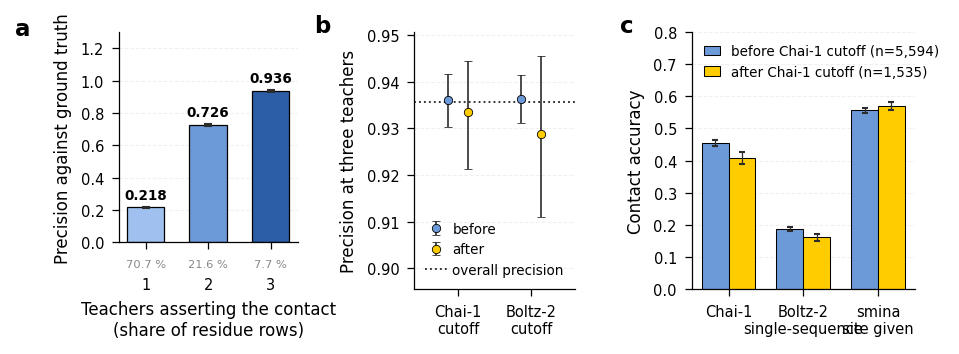

In [7]:
# figure 1: per-residue support, and support and arm accuracy across the training cutoffs
sup, eg, ea = read("support"), read("cutoff_support"), read("cutoff_accuracy")
fig, axes = plt.subplots(1, 3, figsize=(W2, 60 * MM), gridspec_kw={"width_ratios": [1.0, 0.9, 1.25]})
fig.subplots_adjust(wspace=0.62, bottom=0.22)
for a_, f_ in ((axes[0], -0.10), (axes[1], 0.10), (axes[2], 0.10)):   # a shortened from below, b and c extended downwards
    q = a_.get_position(); a_.set_position([q.x0, q.y0 - f_ * q.height, q.width, q.height * (1 + f_)])
ax = axes[0]
ax.bar(sup.level, sup.precision, yerr=[sup.precision - sup.lo, sup.hi - sup.precision], width=0.6,
       color=[COLORS[f"lvl{k}"] for k in sup.level], edgecolor="black", linewidth=0.6,
       error_kw=dict(ecolor=COLORS["reference"], capsize=2, linewidth=0.8))
for _, r in sup.iterrows():
    ax.text(r.level, r.hi + 0.03, f"{r.precision:.3f}", ha="center", va="bottom", fontsize=FS_ANNO, fontweight="bold")
    ax.annotate(f"{100 * r.row_fraction:.1f} %", xy=(r.level, 0), xycoords=("data", "axes fraction"),
                xytext=(0, -8), textcoords="offset points", ha="center", va="top", fontsize=FS_MIN,
                color=COLORS["baseline_ed"], annotation_clip=False)
ax.set_xticks(sup.level); ax.tick_params(axis="x", pad=13)
ax.set(xlabel="Teachers asserting the contact\n(share of residue rows)", ylabel="Precision against ground truth",
       ylim=(0, 1.3))
clean(ax); panel(ax, "a", x=-0.58)

ax = axes[1]
lab = {"chai1": "Chai-1\ncutoff", "boltz2": "Boltz-2\ncutoff"}
for i, m in enumerate(lab):
    for j, e in enumerate(("pre", "post")):
        r = eg[(eg.model == m) & (eg.era == e)].iloc[0]
        ax.errorbar(i + (j - 0.5) * 0.28, r.prec_3, yerr=[[r.prec_3 - r.prec_3_lo], [r.prec_3_hi - r.prec_3]], fmt="o",
                    ms=4, color=COLORS[e], mec="black", mew=0.4, ecolor=COLORS["reference"], elinewidth=0.8, capsize=2,
                    label=("before" if e == "pre" else "after") if i == 0 else None)
ax.axhline(sup.precision.iloc[2], color=COLORS["reference"], linestyle=":", linewidth=0.9, label="overall precision")
ax.set_xticks(range(len(lab))); ax.set_xticklabels(lab.values())
lo_, hi_ = min(eg.prec_3_lo.min(), sup.precision.iloc[2]), max(eg.prec_3_hi.max(), sup.precision.iloc[2])
ax.set(xlim=(-0.6, 1.6), ylim=(lo_ - 0.45 * (hi_ - lo_), hi_ + 0.15 * (hi_ - lo_)), ylabel="Precision at three teachers")
h_, l_ = ax.get_legend_handles_labels()
o_ = [l_.index(k) for k in ("before", "after", "overall precision")]
ax.legend([h_[i] for i in o_], [l_[i] for i in o_], loc="lower center", ncol=1, frameon=False,
          handletextpad=0.4, handlelength=1.6)
clean(ax); panel(ax, "b", x=-0.62)

ax = axes[2]
w = 0.36
for j, e in enumerate(("pre", "post")):
    r = ea[(ea.model == "chai1") & (ea.era == e)].iloc[0]
    v = np.array([r[f"acc_{a}"] for a in ARMS]); lo = np.array([r[f"acc_{a}_lo"] for a in ARMS])
    hi = np.array([r[f"acc_{a}_hi"] for a in ARMS])
    ax.bar(np.arange(3) + (j - 0.5) * w, v, w, yerr=[v - lo, hi - v], color=COLORS[e], edgecolor="black",
           linewidth=0.5, label=f"{'before' if e == 'pre' else 'after'} Chai-1 cutoff (n={int(r.n):,})",
           error_kw=dict(ecolor=COLORS["reference"], capsize=1.5, linewidth=0.6))
ax.set_xticks(range(3)); ax.set_xticklabels(["Chai-1", "Boltz-2\nsingle-sequence", "smina\nsite given"])
ax.set(ylabel="Contact accuracy", ylim=(0, 0.8))
ax.legend(loc="upper left", frameon=False, handlelength=1.2)
clean(ax); panel(ax, "c", x=-0.32)
rb = eg[(eg.model == "chai1") & (eg.era == "post")].iloc[0]
save(fig, "validation_fig1_support",
     f"Panel a, per-residue precision against the ground-truth contact set by the number of teachers asserting the "
     f"contact on the crystal tier, {sup.precision.iloc[0]:.3f}, {sup.precision.iloc[1]:.3f} and "
     f"{sup.precision.iloc[2]:.3f}, with system-clustered bootstrap 95 % intervals and the share of residue rows at "
     f"each level below the axis; union recall {sup.union_recall.iloc[0]:.3f}. Panel b, precision at three asserting "
     f"teachers before and after the Chai-1 and Boltz-2 training cutoffs, with the overall precision as a dotted line; "
     f"after the Chai-1 cutoff it is {rb.prec_3:.3f} ({rb.prec_3_lo:.3f} to {rb.prec_3_hi:.3f}). Panel c, contact "
     f"accuracy of each arm before and after the Chai-1 cutoff; smina has no training cutoff and receives the "
     f"binding site on the crystal tier.")

validation_fig2_calibration: 0.03 MB


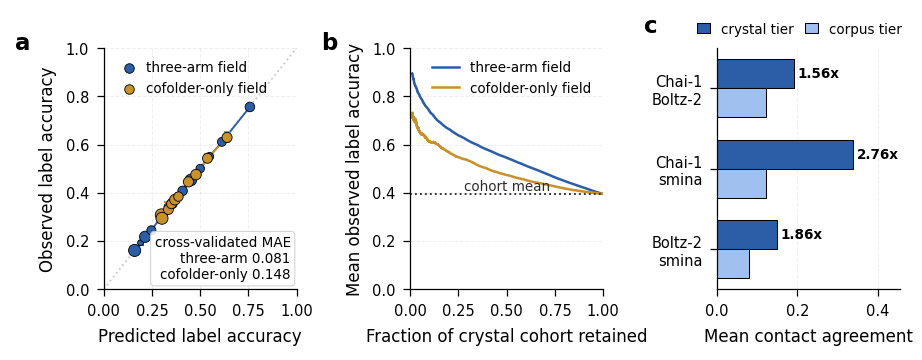

alt_text.md written with 2 entries


In [11]:
# figure 2: calibration of the reliability field, filtering, and binding-site access
sy, pp, bins = read("systems"), read("pairs").set_index("key"), read("calibration_bins")
fig, axes = plt.subplots(1, 3, figsize=(W2, 60 * MM), gridspec_kw={"width_ratios": [1.0, 1.0, 0.95]})
fig.subplots_adjust(wspace=0.6, bottom=0.2)
SER = (("pred_three_arm", "three-arm field", COLORS["field"]), ("pred_site_blind", "cofolder-only field", COLORS["blind"]))
ax = axes[0]
ax.plot([0, 1], [0, 1], color=COLORS["grid"], linestyle=":", linewidth=0.9)
for (c, lbl, col), f in zip(SER, ("three-arm", "cofolder-only")):
    b = bins[bins.field == f]
    s_ = 8 + 26 * (np.log10(b.n) - np.log10(b.n.min())) / max(np.log10(b.n.max()) - np.log10(b.n.min()), 1e-9)
    ax.errorbar(b.predicted, b.observed, yerr=b.ci_half, fmt="none", ecolor=col, elinewidth=0.7, capsize=1.5)
    ax.plot(b.predicted, b.observed, color=col, linewidth=0.9)
    ax.scatter(b.predicted, b.observed, s=s_, color=col, edgecolors="black", linewidths=0.4, zorder=3, label=lbl)
mae_ = {c: np.mean(np.abs(sy.acc - sy[c])) for c, _, _ in SER}
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Predicted label accuracy", ylabel="Observed label accuracy")
ax.legend(loc="upper left", frameon=False, handletextpad=0.2)
note(ax, 0.97, 0.03, f"cross-validated MAE\nthree-arm {mae_['pred_three_arm']:.3f}\n"
                     f"cofolder-only {mae_['pred_site_blind']:.3f}", va="bottom")
clean(ax, grid="both"); panel(ax, "a", x=-0.46)

ax = axes[1]
for c, lbl, col in SER:
    o = np.argsort(-sy[c].values); n_ = np.arange(1, len(o) + 1); k0 = int(0.01 * len(o))   # from 1 % retained
    ax.plot((n_ / len(o))[k0:], (np.cumsum(sy.acc.values[o]) / n_)[k0:], color=col, label=lbl)
refline(ax, sy.acc.mean(), "cohort mean", pos=0.5)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Fraction of crystal cohort retained", ylabel="Mean observed label accuracy")
ax.legend(loc="upper right", frameon=False)
clean(ax); panel(ax, "b", x=-0.46)

ax = axes[2]
names = {"chai1_boltz2": "Chai-1\nBoltz-2", "chai1_smina": "Chai-1\nsmina", "boltz2_smina": "Boltz-2\nsmina"}
yv = np.arange(len(names)); h = 0.36
for j, t in enumerate(("crystal", "corpus")):
    ax.barh(yv + (j - 0.5) * h, pp.loc[list(names), t], h, color=COLORS[t], edgecolor="black", linewidth=0.5,
            label=f"{t} tier")
for i, k in enumerate(names):
    ax.text(pp.loc[k, "crystal"] + 0.01, i - 0.5 * h, f"{pp.loc[k, 'ratio']:.2f}x", va="center", fontsize=FS_ANNO,
            fontweight="bold")
ax.set_yticks(yv); ax.set_yticklabels(names.values()); ax.invert_yaxis()
ax.set(xlabel="Mean contact agreement", xlim=(0, 1.35 * pp.loc[list(names), "crystal"].max()))
ax.legend(loc="lower center", bbox_to_anchor=(0.45, 1.0), ncol=2, frameon=False, handlelength=1.0, columnspacing=0.8)
clean(ax, grid="x"); panel(ax, "c", x=-0.40, y=1.14)
save(fig, "validation_fig2_calibration",
     f"Panel a, observed against cross-validated predicted label accuracy on the crystal tier for the three-arm "
     f"field and a field fitted on cofolder agreement alone, in twelve quantile bins with marker area proportional to "
     f"the logarithm of the bin size and normal 95 % intervals; mean absolute errors {mae_['pred_three_arm']:.3f} and "
     f"{mae_['pred_site_blind']:.3f}. Panel b, mean observed accuracy of the retained systems when the crystal cohort "
     f"is filtered on each field, with the cohort mean as a dotted line. Panel c, mean pairwise contact agreement of "
     f"each teacher pair on the crystal and corpus tiers, with the crystal-to-corpus ratio at the bar end; smina "
     f"receives the binding site on the crystal tier only.")

with open(f"{OUT}/alt_text.md", "w") as fh:
    for k, v in ALT.items(): fh.write(f"## {k}\n\nAlt text: {v}\n\n")
print(f"alt_text.md written with {len(ALT)} entries")

In [9]:
# tmp: every element drawn in figures 1 and 2, read from the exported files the figures use
sup, eg, ea = read("support"), read("cutoff_support"), read("cutoff_accuracy")
sy, pp, bins = read("systems"), read("pairs").set_index("key"), read("calibration_bins")
pd.set_option("display.width", 200)

print("FIGURE 1a  bars: height, error bar ends, value label, label below axis")
print(pd.DataFrame({"teachers": sup.level, "height": sup.precision, "err_low": sup.lo, "err_high": sup.hi,
                    "value_label": sup.precision.map("{:.3f}".format),
                    "below_axis": (100 * sup.row_fraction).map("{:.1f} %".format)}).round(4).to_string(index=False))
print("y axis 0 to 1.3")

print("\nFIGURE 1b  markers: x position, height, error bar ends")
rows = []
for i, m in enumerate(("chai1", "boltz2")):
    for j, e in enumerate(("pre", "post")):
        r = eg[(eg.model == m) & (eg.era == e)].iloc[0]
        rows.append({"cutoff": m, "era": e, "x": i + (j - 0.5) * 0.28, "height": r.prec_3, "err_low": r.prec_3_lo,
                     "err_high": r.prec_3_hi, "n_systems": int(r.n_systems)})
print(pd.DataFrame(rows).round(4).to_string(index=False))
lo_, hi_ = min(eg.prec_3_lo.min(), sup.precision.iloc[2]), max(eg.prec_3_hi.max(), sup.precision.iloc[2])
print(f"dotted line (overall precision) at {sup.precision.iloc[2]:.4f}; "
      f"y axis {lo_ - 0.45 * (hi_ - lo_):.4f} to {hi_ + 0.15 * (hi_ - lo_):.4f}")

print("\nFIGURE 1c  bars (Chai-1 cutoff): height, error bar ends")
rows = []
for e in ("pre", "post"):
    r = ea[(ea.model == "chai1") & (ea.era == e)].iloc[0]
    for a in ARMS:
        rows.append({"era": e, "n": int(r.n), "arm": a, "height": r[f"acc_{a}"], "err_low": r[f"acc_{a}_lo"],
                     "err_high": r[f"acc_{a}_hi"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print("y axis 0 to 0.8; Boltz-2 cutoff values, not drawn:")
print(ea[ea.model == "boltz2"][["era", "n"] + [f"acc_{a}" for a in ARMS]].round(4).to_string(index=False))

print("\nFIGURE 2a  points: x (predicted), y (observed), error half-width, bin size, marker area")
for f in ("three-arm", "cofolder-only"):
    b = bins[bins.field == f].copy()
    b["marker_area"] = 8 + 26 * (np.log10(b.n) - np.log10(b.n.min())) / max(np.log10(b.n.max()) - np.log10(b.n.min()), 1e-9)
    print(f"\n{f}\n" + b[["predicted", "observed", "ci_half", "gap", "n", "marker_area"]].round(4).to_string(index=False))
print("\nnote box: " + ", ".join(f"{c} MAE {np.mean(np.abs(sy.acc - sy[c])):.4f}" for c in ("pred_three_arm", "pred_site_blind")))
print("axes 0 to 1, diagonal dotted")

print("\nFIGURE 2b  curves: mean observed accuracy of the retained systems at selected x")
fr = np.array([0.01, 0.02, 0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.90, 1.00])
cur = {}
for c in ("pred_three_arm", "pred_site_blind"):
    o = np.argsort(-sy[c].values); cm = np.cumsum(sy.acc.values[o]) / np.arange(1, len(o) + 1)
    cur[c] = [cm[max(int(f * len(o)) - 1, 0)] for f in fr]
cur = pd.DataFrame(cur, index=pd.Index(fr, name="retained")); cur["difference"] = cur.pred_three_arm - cur.pred_site_blind
print(cur.round(4).to_string() + f"\ndotted line (cohort mean) at {sy.acc.mean():.4f}; curves start at 1 % retained; axes 0 to 1")

print("\nFIGURE 2c  horizontal bars: length, ratio label")
print(pp.assign(ratio_label=pp.ratio.map("{:.2f}x".format)).round(4).to_string())
print(f"x axis 0 to {1.35 * pp.crystal.max():.4f}")

FIGURE 1a  bars: height, error bar ends, value label, label below axis
 teachers  height  err_low  err_high value_label below_axis
        1  0.2175   0.2143    0.2204       0.218     70.7 %
        2  0.7265   0.7180    0.7343       0.726     21.6 %
        3  0.9356   0.9304    0.9404       0.936      7.7 %
y axis 0 to 1.3

FIGURE 1b  markers: x position, height, error bar ends
cutoff  era     x  height  err_low  err_high  n_systems
 chai1  pre -0.14  0.9361   0.9304    0.9415       5594
 chai1 post  0.14  0.9336   0.9212    0.9444       1535
boltz2  pre  0.86  0.9363   0.9311    0.9414       6391
boltz2 post  1.14  0.9288   0.9110    0.9454        738
dotted line (overall precision) at 0.9356; y axis 0.8955 to 0.9506

FIGURE 1c  bars (Chai-1 cutoff): height, error bar ends
 era    n    arm  height  err_low  err_high
 pre 5594  chai1  0.4544   0.4450    0.4636
 pre 5594 boltz2  0.1871   0.1809    0.1930
 pre 5594  smina  0.5566   0.5486    0.5641
post 1535  chai1  0.4075   0.3891    

In [9]:
print(f"section runtime {time.time() - T0:.0f} s cumulative")

In [10]:
print(f"section runtime {time.time() - T0:.0f} s cumulative")

section runtime 78 s cumulative
